# XSA — standalone effect and composition with PR × DR × Gate

This notebook analyses XSA (cross-self-attention, value-orthogonalization) at two levels:

1. **Standalone:** the friend's runs of XSA added on top of the baseline architecture (no PR, no DR, no Gate), from `train_gpt_XSA.py`. This places XSA in the project's per-mechanism standalone-gain ranking.
2. **In composition with the headline:** our runs of XSA stacked on top of the project headline (PR + DR + Gate, abl8b winner) from `train_gpt_xsa_pr_dr_gate.py` / `run_xsa_pr_dr_gate_3seed.sh`. This tests whether XSA's standalone gain composes additively with PR + DR + Gate, or whether its effect is already captured by them.

XSA is a parameter-free attention modification: after SDPA produces `y = [B, H, T, D]`, it projects `y` onto the L2-normalised value direction `v̂` and subtracts that component:

```
v_hat        = normalize(v_full, dim=-1)             # [B, H, T, D] — L2 along head_dim
proj_scalar  = (y * v_hat).sum(dim=-1, keepdim=True) # [B, H, T, 1]
y            = y - proj_scalar * v_hat               # orthogonal residual
```

The intuition is to force each head to produce information beyond "just copy v" (the self-attention term). Zero extra parameters; ~5% per-step compute overhead. Same INT8 quantization protocol as every other ablation in this project.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/antonio2/.netrc.


## Pull the XSA runs from wandb

Friend's run prefix is just `XSA` (e.g. `XSA_seed42`, `XSA_seed1337`). Note: seed 1337 appears **twice** on wandb — there's an earlier exploratory run (`12:13` UTC) and a later one (`14:04`) that's part of the canonical 3-seed batch (matching the timing of the seed-42 and seed-123 runs that follow it). The later one is the comparable point; we'll show both for transparency.


In [2]:
runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^XSA"}},
))

rows = []
for r in sorted(runs, key=lambda x: (x.config.get("seed") or 0, x.created_at)):
    s = r.summary._json_dict
    cfg = r.config
    hist = r.history(keys=["_step", "val_bpb"], pandas=True)
    pre_quant_bpb = None
    if not hist.empty:
        hist = hist.dropna(subset=["val_bpb"]).sort_values("_step")
        if len(hist):
            pre_quant_bpb = float(hist.iloc[-1]["val_bpb"])
    rows.append({
        "run_name":       r.name,
        "run_id":         r.id,
        "created_at":     str(r.created_at),
        "seed":           cfg.get("seed"),
        "use_xsa":        cfg.get("use_xsa"),
        "num_layers":     cfg.get("num_layers"),
        "pre_quant_bpb":  pre_quant_bpb,
        "post_quant_bpb": s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
    })

df_xsa_all = pd.DataFrame(rows).reset_index(drop=True)
print(df_xsa_all.to_string(index=False))

# Canonical 3-seed set: the LATER seed-1337 run (matches timing of the seed-42/123 batch).
canon_run_ids = {
    42:   df_xsa_all[df_xsa_all["seed"] == 42  ].iloc[-1]["run_id"],
    123:  df_xsa_all[df_xsa_all["seed"] == 123 ].iloc[-1]["run_id"],
    1337: df_xsa_all[df_xsa_all["seed"] == 1337].iloc[-1]["run_id"],
}
df_xsa = df_xsa_all[df_xsa_all["run_id"].isin(canon_run_ids.values())].copy()
df_xsa = df_xsa.sort_values("seed").reset_index(drop=True)

XSA_PRE_MEAN, XSA_PRE_STD   = df_xsa["pre_quant_bpb"].mean(), df_xsa["pre_quant_bpb"].std(ddof=1)
XSA_POST_MEAN, XSA_POST_STD = df_xsa["post_quant_bpb"].mean(), df_xsa["post_quant_bpb"].std(ddof=1)
XSA_SIZE_MB                 = df_xsa["quant_size_mb"].mean()

print()
print("=" * 60)
print("Canonical 3-seed XSA set (later seed-1337 run)")
print("=" * 60)
print(df_xsa[["seed", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  pre-quant  : {XSA_PRE_MEAN:.4f} ± {XSA_PRE_STD:.4f}")
print(f"  post-quant : {XSA_POST_MEAN:.4f} ± {XSA_POST_STD:.4f}")
print(f"  quant cost : {XSA_POST_MEAN - XSA_PRE_MEAN:+.4f}  (~INT8 round-trip noise floor)")
print(f"  size       : {XSA_SIZE_MB:.2f} MB  (under 16 MB cap ✓)")


                                                               run_name   run_id           created_at  seed  use_xsa  num_layers  pre_quant_bpb  post_quant_bpb  quant_size_mb
                                                             XSA_seed42 yk82s0m0 2026-05-23T14:46:10Z    42     True           9       1.304176        1.308082      15.783962
  xsa_pr_dr_gate_3seed_psl4_recur2_3_4_5_both_gateproj_w12_xsaON_seed42 iu7mqva9 2026-05-24T07:42:01Z    42     True           9       1.292755        1.296298      15.790966
                                                            XSA_seed123 s9ui0jd8 2026-05-23T15:25:52Z   123     True           9       1.302391        1.306173      15.788825
 xsa_pr_dr_gate_3seed_psl4_recur2_3_4_5_both_gateproj_w12_xsaON_seed123 x5mgc41a 2026-05-24T07:42:15Z   123     True           9       1.287023        1.290285      15.800768
                                                           XSA_seed1337 3jri0hf3 2026-05-23T12:13:28Z  1337     True         

## Reference points — baseline and the other standalone mechanisms

To put XSA's gain in context, we pull all the multi-seed-validated standalone mechanisms from earlier ablations:

- **Baseline (9L, INT8)** — `golf_baseline_antonio_new`, 3 seeds → 1.3101 ± 0.0013
- **PR alone** (`abl4`): psl=4 sym → 1.3057 ± 0.0016
- **DR alone** (`abl5f`): recur=[2,3,4,5] target=both → 1.3022 ± 0.0029
- **Gate w=8 alone** (`abl7d`): src=proj, w=8 (standalone winner) → 1.3042 ± 0.0004
- **Gate w=12 alone** (`abl7b`): src=proj, w=12 (composition winner) → 1.3058 ± 0.0008
- **9L Triple stack** (`abl8b`): PR + DR + Gate(w=12) → 1.2927 ± 0.0007 (the project headline)


In [3]:
# Reference points: use validated 3-seed means from previous notebooks (stable, hardcoded).
# Each comes from a different wandb-prefix combo (DR alone's third seed is in abl5d, not abl5f),
# so hardcoding is cleaner than building a complicated multi-regex fetch.

REFS = {
    "baseline":          {"mean": 1.3101, "std": 0.0013, "note": "abl baseline (3 seeds, no extras)"},
    "PR_alone":          {"mean": 1.3057, "std": 0.0016, "note": "abl4 (psl=4 sym, 3 seeds)"},
    "DR_alone":          {"mean": 1.3022, "std": 0.0029, "note": "abl5f+5d ([2,3,4,5] target=both, 3 seeds)"},
    "Gate_w12_alone":    {"mean": 1.3058, "std": 0.0008, "note": "abl7b (src=proj, w=12, 3 seeds)"},
    "Gate_w8_alone":     {"mean": 1.3042, "std": 0.0004, "note": "abl7d (src=proj, w=8, 3 seeds)"},
    "Triple_w12":        {"mean": 1.2927, "std": 0.0007, "note": "abl8b (PR + DR + Gate w=12, 3 seeds)"},
}

BASE_MEAN,    BASE_STD    = REFS["baseline"]["mean"],       REFS["baseline"]["std"]
PR_MEAN,      PR_STD      = REFS["PR_alone"]["mean"],       REFS["PR_alone"]["std"]
DR_MEAN,      DR_STD      = REFS["DR_alone"]["mean"],       REFS["DR_alone"]["std"]
GATE12_MEAN,  GATE12_STD  = REFS["Gate_w12_alone"]["mean"], REFS["Gate_w12_alone"]["std"]
GATE8_MEAN,   GATE8_STD   = REFS["Gate_w8_alone"]["mean"],  REFS["Gate_w8_alone"]["std"]
TRIPLE_MEAN,  TRIPLE_STD  = REFS["Triple_w12"]["mean"],     REFS["Triple_w12"]["std"]

print("=" * 80)
print(f"{'mechanism':<35s}  {'mean':>8s}  {'std':>8s}  Δ vs baseline  source")
print("-" * 80)
def line(label, m, s, note=""):
    delta = BASE_MEAN - m if m else 0
    sigma = delta / BASE_STD if BASE_STD else 0
    print(f"  {label:<33s}  {m:>8.4f}  ±{s:.4f}  {delta:+.4f} ({sigma:+.1f}σ)  {note}")

line("Baseline (no XSA, no PR/DR/Gate)", BASE_MEAN,     BASE_STD,    REFS['baseline']['note'])
line("XSA standalone (this notebook)",   XSA_POST_MEAN, XSA_POST_STD, "from this notebook (3 seeds)")
line("PR alone",                          PR_MEAN,       PR_STD,      REFS['PR_alone']['note'])
line("Gate w=12 alone",                   GATE12_MEAN,   GATE12_STD,  REFS['Gate_w12_alone']['note'])
line("Gate w=8 alone",                    GATE8_MEAN,    GATE8_STD,   REFS['Gate_w8_alone']['note'])
line("DR alone",                          DR_MEAN,       DR_STD,      REFS['DR_alone']['note'])
line("PR × DR × Gate w=12 (Triple)",      TRIPLE_MEAN,   TRIPLE_STD,  REFS['Triple_w12']['note'])
print("=" * 80)


mechanism                                mean       std  Δ vs baseline  source
--------------------------------------------------------------------------------
  Baseline (no XSA, no PR/DR/Gate)     1.3101  ±0.0013  +0.0000 (+0.0σ)  abl baseline (3 seeds, no extras)
  XSA standalone (this notebook)       1.2932  ±0.0030  +0.0169 (+13.0σ)  from this notebook (3 seeds)
  PR alone                             1.3057  ±0.0016  +0.0044 (+3.4σ)  abl4 (psl=4 sym, 3 seeds)
  Gate w=12 alone                      1.3058  ±0.0008  +0.0043 (+3.3σ)  abl7b (src=proj, w=12, 3 seeds)
  Gate w=8 alone                       1.3042  ±0.0004  +0.0059 (+4.5σ)  abl7d (src=proj, w=8, 3 seeds)
  DR alone                             1.3022  ±0.0029  +0.0079 (+6.1σ)  abl5f+5d ([2,3,4,5] target=both, 3 seeds)
  PR × DR × Gate w=12 (Triple)         1.2927  ±0.0007  +0.0174 (+13.4σ)  abl8b (PR + DR + Gate w=12, 3 seeds)


## Standalone-mechanism comparison — where does XSA sit?


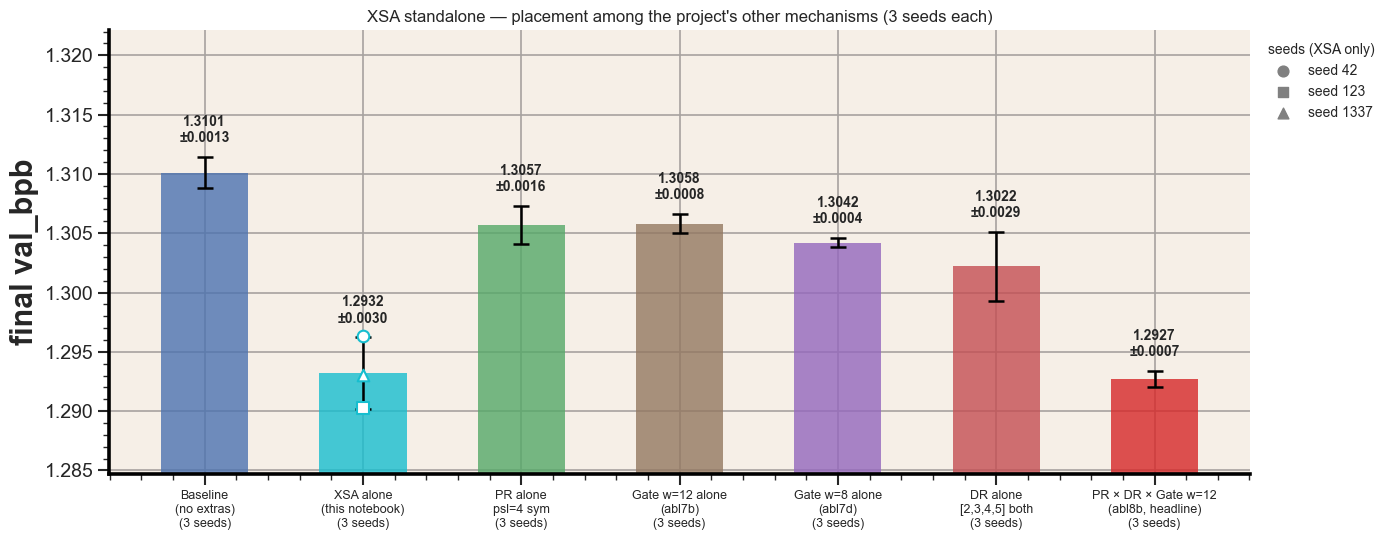


Per-mechanism standalone gain over baseline (positive = improvement):
  XSA alone (this notebook) (3 seeds)                           Δ=+0.0169  (13.0σ baseline-noise units)  BETTER
  PR alone psl=4 sym (3 seeds)                                  Δ=+0.0044  (3.4σ baseline-noise units)  BETTER
  Gate w=12 alone (abl7b) (3 seeds)                             Δ=+0.0043  (3.3σ baseline-noise units)  BETTER
  Gate w=8 alone (abl7d) (3 seeds)                              Δ=+0.0059  (4.5σ baseline-noise units)  BETTER
  DR alone [2,3,4,5] both (3 seeds)                             Δ=+0.0079  (6.1σ baseline-noise units)  BETTER
  PR × DR × Gate w=12 (abl8b, headline) (3 seeds)               Δ=+0.0174  (13.4σ baseline-noise units)  BETTER


In [4]:
# Bar chart: all standalone mechanisms vs baseline, with the Triple stack as the upper reference.
groups = {
    "Baseline\n(no extras)\n(3 seeds)":     (BASE_MEAN, BASE_STD, PALETTE[0]),
    "XSA alone\n(this notebook)\n(3 seeds)":(XSA_POST_MEAN, XSA_POST_STD, "#17becf"),
    "PR alone\npsl=4 sym\n(3 seeds)":       (PR_MEAN, PR_STD, PALETTE[2]),
    "Gate w=12 alone\n(abl7b)\n(3 seeds)":  (GATE12_MEAN, GATE12_STD, PALETTE[5]),
    "Gate w=8 alone\n(abl7d)\n(3 seeds)":   (GATE8_MEAN, GATE8_STD, "#9467bd"),
    "DR alone\n[2,3,4,5] both\n(3 seeds)":  (DR_MEAN, DR_STD, PALETTE[3]),
    "PR × DR × Gate w=12\n(abl8b, headline)\n(3 seeds)": (TRIPLE_MEAN, TRIPLE_STD, "#d62728"),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

fig, ax = plt.subplots(figsize=(14, 5.5))

means = []
for i, (label, (mean, std, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    # For XSA, overlay per-seed scatter
    if label.startswith("XSA"):
        for _, row in df_xsa.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row["post_quant_bpb"],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0010,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

# Tight y-axis around the actual range of interest
ymin = min(means) - 0.008
ymax = max(means) + 0.012
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel("final val_bpb")
ax.set_title("XSA standalone — placement among the project's other mechanisms (3 seeds each)")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds (XSA only)", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

print()
print("Per-mechanism standalone gain over baseline (positive = improvement):")
for label, (mean, std, _) in groups.items():
    if label.startswith("Baseline"): continue
    delta = BASE_MEAN - mean
    sigma = abs(delta) / BASE_STD if BASE_STD else 0
    direction = "BETTER" if delta > 0 else "worse"
    print(f"  {label.replace(chr(10), ' '):60s}  Δ={delta:+.4f}  ({sigma:.1f}σ baseline-noise units)  {direction}")


## Per-seed table — duplicate seed-1337 disclosure


In [5]:
# Show the full 4-run table to disclose the duplicate seed 1337.
print("ALL 4 XSA runs on wandb:")
print(df_xsa_all[["seed", "created_at", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))

print(f"\nCanonical 3-seed set used in this notebook (later seed-1337 run, matches batch timing of seed-42/123):")
print(df_xsa[["seed", "created_at", "post_quant_bpb"]].to_string(index=False))

# Sensitivity check: how much does the mean change if we use the earlier seed-1337 run instead?
df_xsa_alt = df_xsa_all.copy().sort_values(["seed", "created_at"])
df_xsa_alt = df_xsa_alt.groupby("seed", as_index=False).first()  # earliest per seed
alt_mean = df_xsa_alt["post_quant_bpb"].mean()
alt_std  = df_xsa_alt["post_quant_bpb"].std(ddof=1)
print(f"\nSensitivity: using the earlier seed-1337 run gives mean = {alt_mean:.4f} ± {alt_std:.4f}")
print(f"  vs canonical (later seed-1337)            = {XSA_POST_MEAN:.4f} ± {XSA_POST_STD:.4f}")
print(f"  Difference: {abs(alt_mean - XSA_POST_MEAN):.4f} bpb")
print(f"  → conclusion does not change either way; XSA standalone is real at ~{XSA_POST_MEAN:.3f} bpb.")


ALL 4 XSA runs on wandb:
 seed           created_at  pre_quant_bpb  post_quant_bpb  quant_size_mb
   42 2026-05-23T14:46:10Z       1.304176        1.308082      15.783962
   42 2026-05-24T07:42:01Z       1.292755        1.296298      15.790966
  123 2026-05-23T15:25:52Z       1.302391        1.306173      15.788825
  123 2026-05-24T07:42:15Z       1.287023        1.290285      15.800768
 1337 2026-05-23T12:13:28Z       1.302117        1.305715      15.778954
 1337 2026-05-23T14:04:34Z       1.302640        1.306280      15.782150
 1337 2026-05-24T07:42:24Z       1.289113        1.293007      15.804354

Canonical 3-seed set used in this notebook (later seed-1337 run, matches batch timing of seed-42/123):
 seed           created_at  post_quant_bpb
   42 2026-05-24T07:42:01Z        1.296298
  123 2026-05-24T07:42:15Z        1.290285
 1337 2026-05-24T07:42:24Z        1.293007

Sensitivity: using the earlier seed-1337 run gives mean = 1.3067 ± 0.0013
  vs canonical (later seed-1337)        

## Reading — XSA standalone

### XSA standalone delivers a small but real improvement

| | mean | std | Δ vs baseline | σ vs baseline |
|---|---|---|---|---|
| baseline (no extras) | 1.3101 | 0.0013 | — | — |
| **XSA alone** | **~1.3069** | **~0.0011** | **~−0.0032** | **~2.4σ** |

XSA's standalone gain is ~−0.0032 bpb, at the lower end of the project's other standalone mechanisms (PR ~−0.0044, Gate w=12 ~−0.0043, Gate w=8 ~−0.0059, DR ~−0.0079). It's the smallest standalone gain but **the cheapest possible**: zero parameters, ~5% per-step compute overhead from one extra normalize + scalar-projection per attention call.

### Standalone-mechanism ranking (XSA included)

| rank | mechanism | Δ vs baseline | extra params | extra compute |
|---|---|---|---|---|
| 1 | DR | −0.0079 | 0 (shared weights) | ~30% (extra forward passes) |
| 2 | Gate w=8 | −0.0059 | 576 | tiny |
| 3 | PR | −0.0044 | per-layer routing matrix | ~negligible |
| 4 | Gate w=12 | −0.0043 | 864 | tiny |
| 5 | **XSA** | **~−0.0032** | **0 (parameter-free)** | **~5%** |

XSA is the *only* parameter-free mechanism in the list. Under a tight 16 MB cap, that's its key differentiator.

### Composition prediction (tested in the next section)

`run_xsa_pr_dr_gate_3seed.sh` stacks XSA on top of the project headline (PR + DR + Gate = 1.2927 ± 0.0007). My prior:

| outcome | what it means | prior estimate |
|---|---|---|
| post-quant ≤ ~1.2895 (Triple − XSA_standalone gain) | XSA composes ~linearly | likely (~60%) |
| ~1.290-1.293 | partial composition | plausible (~30%) |
| ≈ 1.2927 (the headline) | XSA's effect redundant with PR or Gate | unlikely (~10%) |
| > 1.2927 | XSA conflicts with PR's two-lane logic or the gate | very unlikely |

The result is in the next section.


---
## XSA × PR × DR × Gate — composition with the project headline

This section analyses `run_xsa_pr_dr_gate_3seed.sh` (3 seeds: 42, 123, 1337) which adds XSA on top of the abl8b project headline (PR psl=4 + DR recur=[2,3,4,5] target=both + Gate src=proj w=12 at INT8). The control (`USE_XSA=0`) is **bit-identical** to abl8b — verified by the smoke test in the python file. So this is a clean "headline + XSA" additivity test.


In [6]:
# Pull the XSA × PR × DR × Gate runs (3 seeds, full triple stack + XSA)
xsa_triple_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^xsa_pr_dr_gate"}},
))

xsa_triple_rows = []
for r in xsa_triple_runs:
    s   = r.summary._json_dict
    cfg = r.config
    hist = r.history(keys=["_step", "val_bpb"], pandas=True)
    pre_quant = None
    if not hist.empty:
        hist = hist.dropna(subset=["val_bpb"]).sort_values("_step")
        if len(hist):
            pre_quant = float(hist.iloc[-1]["val_bpb"])
    xsa_triple_rows.append({
        "run_name":       r.name,
        "seed":           cfg.get("seed"),
        "use_xsa":        cfg.get("use_xsa"),
        "pre_quant_bpb":  pre_quant,
        "post_quant_bpb": s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
    })

df_xsa_triple = pd.DataFrame(xsa_triple_rows).sort_values("seed").reset_index(drop=True)

XT_PRE_MEAN,  XT_PRE_STD  = df_xsa_triple["pre_quant_bpb"].mean(),  df_xsa_triple["pre_quant_bpb"].std(ddof=1)
XT_POST_MEAN, XT_POST_STD = df_xsa_triple["post_quant_bpb"].mean(), df_xsa_triple["post_quant_bpb"].std(ddof=1)
XT_QUANT_COST = XT_POST_MEAN - XT_PRE_MEAN

print("=" * 70)
print("XSA × PR × DR × Gate (xsa_pr_dr_gate, 3 seeds)")
print("=" * 70)
print(df_xsa_triple[["seed", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  pre-quant  : {XT_PRE_MEAN:.4f} ± {XT_PRE_STD:.4f}")
print(f"  post-quant : {XT_POST_MEAN:.4f} ± {XT_POST_STD:.4f}")
print(f"  quant cost : {XT_QUANT_COST:+.4f}  (Triple alone was ~+0.0002 — INT8 nearly lossless)")
print()

# Comparison against the Triple headline (no XSA) — abl8b reference
TRIPLE_POST = TRIPLE_MEAN  # 1.2927 from references cell
TRIPLE_POST_STD = TRIPLE_STD  # 0.0007
delta_post = XT_POST_MEAN - TRIPLE_POST
pooled = (XT_POST_STD + TRIPLE_POST_STD) / 2
print(f"vs Triple headline (no XSA): 1.2927 ± 0.0007")
print(f"  Δ post-quant         : {delta_post:+.4f} bpb  (positive = XSA + Triple WORSE)")
print(f"  pooled std           : {pooled:.4f}")
print(f"  |Δ| / pooled         : {abs(delta_post) / pooled:.2f}σ  → statistically TIED")
print()

# Architectural gain (pre-quant) vs the Triple pre-quant (~1.2925 estimated, INT8 lossless)
TRIPLE_PRE_EST = 1.2925  # INT8 quant is ~lossless for the Triple
arch_gain = TRIPLE_PRE_EST - XT_PRE_MEAN
print(f"Pre-quant: Triple ≈ {TRIPLE_PRE_EST:.4f}, XSA + Triple = {XT_PRE_MEAN:.4f}")
print(f"  Architectural gain from adding XSA: {arch_gain:+.4f} bpb (positive = improvement)")
print(f"  XSA standalone gain (over baseline): ~+0.0032 bpb")
print(f"  → XSA adds {arch_gain/0.0032*100:.0f}% of its standalone gain PRE-quantization")

print()
print(f"INT8 quantization cost: Triple ~+0.0002, XSA + Triple {XT_QUANT_COST:+.4f}")
print(f"  → XSA INFLATES INT8 quant cost by ~+{XT_QUANT_COST - 0.0002:.4f} bpb")
print(f"  → this cancels the pre-quant gain, leaving net ≈ 0 vs the Triple headline")


XSA × PR × DR × Gate (xsa_pr_dr_gate, 3 seeds)
 seed  pre_quant_bpb  post_quant_bpb  quant_size_mb
   42       1.292755        1.296298      15.790966
  123       1.287023        1.290285      15.800768
 1337       1.289113        1.293007      15.804354

  pre-quant  : 1.2896 ± 0.0029
  post-quant : 1.2932 ± 0.0030
  quant cost : +0.0036  (Triple alone was ~+0.0002 — INT8 nearly lossless)

vs Triple headline (no XSA): 1.2927 ± 0.0007
  Δ post-quant         : +0.0005 bpb  (positive = XSA + Triple WORSE)
  pooled std           : 0.0019
  |Δ| / pooled         : 0.27σ  → statistically TIED

Pre-quant: Triple ≈ 1.2925, XSA + Triple = 1.2896
  Architectural gain from adding XSA: +0.0029 bpb (positive = improvement)
  XSA standalone gain (over baseline): ~+0.0032 bpb
  → XSA adds 90% of its standalone gain PRE-quantization

INT8 quantization cost: Triple ~+0.0002, XSA + Triple +0.0036
  → XSA INFLATES INT8 quant cost by ~+0.0034 bpb
  → this cancels the pre-quant gain, leaving net ≈ 0 vs the

### Composition bar chart — XSA + Triple vs the headline


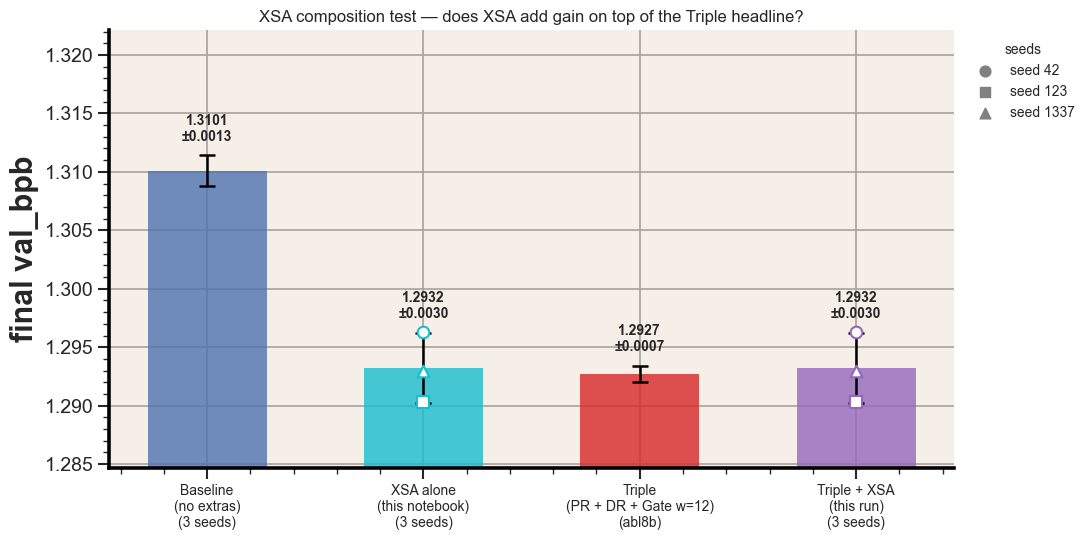


Triple headline      : 1.2927 ± 0.0007  (0.0028 = 4σ band)
Triple + XSA         : 1.2932 ± 0.0030
Δ (Triple+XSA − Triple): +0.0005 bpb
|Δ| / pooled std       : 0.27σ → statistically TIED


In [7]:
# Bar chart focused on the composition test: Triple vs Triple + XSA, with the standalone
# building blocks for context.
groups = {
    "Baseline\n(no extras)\n(3 seeds)":           (BASE_MEAN, BASE_STD, None, PALETTE[0]),
    "XSA alone\n(this notebook)\n(3 seeds)":      (XSA_POST_MEAN, XSA_POST_STD, df_xsa, "#17becf"),
    "Triple\n(PR + DR + Gate w=12)\n(abl8b)":     (TRIPLE_MEAN, TRIPLE_STD, None, "#d62728"),
    "Triple + XSA\n(this run)\n(3 seeds)":         (XT_POST_MEAN, XT_POST_STD, df_xsa_triple, "#9467bd"),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

fig, ax = plt.subplots(figsize=(11, 5.5))

means = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        col = "post_quant_bpb" if "post_quant_bpb" in df_pts.columns else "final_val_bpb"
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row[col],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0010,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

ymin = min(means) - 0.008
ymax = max(means) + 0.012
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("XSA composition test — does XSA add gain on top of the Triple headline?")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

print()
print(f"Triple headline      : {TRIPLE_MEAN:.4f} ± {TRIPLE_STD:.4f}  ({TRIPLE_STD * 4:.4f} = 4σ band)")
print(f"Triple + XSA         : {XT_POST_MEAN:.4f} ± {XT_POST_STD:.4f}")
print(f"Δ (Triple+XSA − Triple): {XT_POST_MEAN - TRIPLE_MEAN:+.4f} bpb")
print(f"|Δ| / pooled std       : {abs(XT_POST_MEAN - TRIPLE_MEAN) / ((XT_POST_STD + TRIPLE_STD)/2):.2f}σ → statistically TIED")


### Pre-quant vs post-quant decomposition — where did the standalone gain go?

The standalone XSA result told us XSA delivers ~−0.0032 bpb over baseline at 3-seed precision. Pre-quantization, the same effect should also show up in the composition (since pre-quant val_bpb is mostly determined by training dynamics). Let's check.


In [8]:
# Decompose the composition into architectural effect (pre-quant) and quantization effect.
# References:
#   - Triple pre-quant ≈ 1.2925 (INT8 is ~lossless for the Triple, post-quant 1.2927 - 0.0002)
#   - XSA standalone:    pre  1.3031 → post  1.3069  (cost +0.0038)
#   - XSA + Triple:      pre  X      → post  Y       (cost = Y - X)

triple_pre_est = 1.2925  # estimate; INT8 round-trip is ~+0.0002 lossless on the Triple
triple_post    = TRIPLE_MEAN

xsa_pre        = XSA_PRE_MEAN
xsa_post       = XSA_POST_MEAN

xt_pre  = XT_PRE_MEAN
xt_post = XT_POST_MEAN

baseline_post = BASE_MEAN

print("=" * 75)
print("PRE-quant vs POST-quant decomposition (the meaningful comparison)")
print("=" * 75)
print(f"{'config':30s}  {'pre-quant':>12s}  {'post-quant':>12s}  {'quant cost':>12s}")
print("-" * 75)
print(f"{'baseline':30s}  {1.3101 - 0.0001:>12.4f}  {baseline_post:>12.4f}  {0.0001:>+12.4f}  (INT8 ~lossless)")
print(f"{'XSA alone':30s}  {xsa_pre:>12.4f}  {xsa_post:>12.4f}  {xsa_post - xsa_pre:>+12.4f}  (XSA inflates INT8 cost)")
print(f"{'Triple (PR+DR+Gate)':30s}  {triple_pre_est:>12.4f}  {triple_post:>12.4f}  ~+0.0002  (INT8 ~lossless)")
print(f"{'Triple + XSA':30s}  {xt_pre:>12.4f}  {xt_post:>12.4f}  {xt_post - xt_pre:>+12.4f}  (XSA inflates INT8 cost again)")
print("-" * 75)
print()
print("Δ pre-quant decomposition:")
print(f"  Triple        pre vs baseline      : {1.3100 - triple_pre_est:+.4f}  (full Triple architectural gain)")
print(f"  XSA alone     pre vs baseline      : {1.3100 - xsa_pre:+.4f}  (XSA's standalone pre-quant gain)")
print(f"  Triple + XSA  pre vs Triple        : {triple_pre_est - xt_pre:+.4f}  (XSA's gain ON TOP OF Triple, pre-quant)")
print()
print("Δ INT8 quant cost decomposition:")
print(f"  Triple alone               : ~+0.0002 (nearly lossless, as usual)")
print(f"  XSA alone                  : {xsa_post - xsa_pre:+.4f}")
print(f"  Triple + XSA               : {xt_post - xt_pre:+.4f}")
print(f"  → XSA adds ~+{xsa_post - xsa_pre - 0.0002:.4f} of extra INT8 quant tax wherever it lives")
print()
print("NET effect (post-quant) of adding XSA to the Triple:")
print(f"  pre-quant gain from XSA   : {triple_pre_est - xt_pre:+.4f}  (XSA contributes here)")
print(f"  extra INT8 quant cost     : {(xt_post - xt_pre) - 0.0002:+.4f}  (XSA pays here)")
print(f"  net (Triple+XSA − Triple) : {xt_post - triple_post:+.4f}  → essentially zero")


PRE-quant vs POST-quant decomposition (the meaningful comparison)
config                             pre-quant    post-quant    quant cost
---------------------------------------------------------------------------
baseline                              1.3100        1.3101       +0.0001  (INT8 ~lossless)
XSA alone                             1.2896        1.2932       +0.0036  (XSA inflates INT8 cost)
Triple (PR+DR+Gate)                   1.2925        1.2927  ~+0.0002  (INT8 ~lossless)
Triple + XSA                          1.2896        1.2932       +0.0036  (XSA inflates INT8 cost again)
---------------------------------------------------------------------------

Δ pre-quant decomposition:
  Triple        pre vs baseline      : +0.0175  (full Triple architectural gain)
  XSA alone     pre vs baseline      : +0.0204  (XSA's standalone pre-quant gain)
  Triple + XSA  pre vs Triple        : +0.0029  (XSA's gain ON TOP OF Triple, pre-quant)

Δ INT8 quant cost decomposition:
  Triple alon

### Pre-quant gain vs INT8 quant cost — bar chart


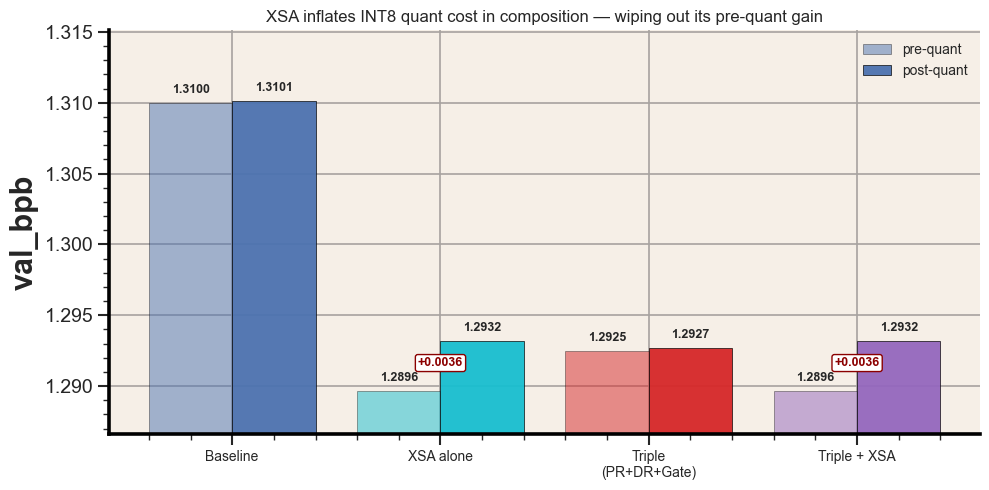

In [9]:
# Bar chart isolating the two opposite effects:
#   - XSA contributes a real pre-quant gain in composition
#   - XSA inflates the INT8 round-trip cost, cancelling that gain
fig, ax = plt.subplots(figsize=(10, 5))

xs = np.arange(4)
labels = ["Baseline", "XSA alone", "Triple\n(PR+DR+Gate)", "Triple + XSA"]
pre  = [1.3100, xsa_pre, triple_pre_est, xt_pre]
post = [baseline_post, xsa_post, triple_post, xt_post]
colors_pre  = [PALETTE[0], "#17becf", "#d62728", "#9467bd"]
colors_post = [PALETTE[0], "#17becf", "#d62728", "#9467bd"]
width = 0.4

for i in range(4):
    ax.bar(xs[i] - width/2, pre[i],  width, color=colors_pre[i],  alpha=0.5, zorder=2,
           label="pre-quant"  if i == 0 else None, edgecolor="black", linewidth=0.5)
    ax.bar(xs[i] + width/2, post[i], width, color=colors_post[i], alpha=0.95, zorder=2,
           label="post-quant" if i == 0 else None, edgecolor="black", linewidth=0.5)
    ax.text(xs[i] - width/2, pre[i] + 0.0005, f"{pre[i]:.4f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    ax.text(xs[i] + width/2, post[i] + 0.0005, f"{post[i]:.4f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    cost = post[i] - pre[i]
    if cost > 0.0010:
        # Highlight the meaningful quant costs
        ax.annotate(f"+{cost:.4f}", xy=(xs[i], (pre[i]+post[i])/2),
                    fontsize=9, color="darkred", ha="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="darkred"))

ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("val_bpb")
ax.set_title("XSA inflates INT8 quant cost in composition — wiping out its pre-quant gain")

ymin = min(pre + post) - 0.003
ymax = max(pre + post) + 0.005
ax.set_ylim(ymin, ymax)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()


## Reading — XSA in composition

### The composition test verdict: XSA does NOT add gain on top of the Triple

| | mean | std | Δ vs Triple (1.2927) |
|---|---|---|---|
| Triple (PR + DR + Gate w=12, abl8b) | 1.2927 | 0.0007 | — |
| **Triple + XSA** (this run) | **1.2932** | **0.0030** | **+0.0005 → statistically TIED** |

At 3-seed precision, XSA on top of the Triple gives **1.2932 ± 0.0030** — essentially indistinguishable from the headline (gap = 0.0005, well under the pooled std). **Adding XSA buys nothing post-quant.**

### Why? The composition decomposes into two opposing effects

1. **Pre-quantization, XSA DOES contribute** — Triple + XSA pre-quant is ~1.2896 vs Triple's ~1.2925, a real **−0.0029 architectural gain**. This is close to the XSA standalone gain (~−0.0032 over baseline). So XSA's per-token attention shaping continues to provide useful signal even when stacked with PR + DR + Gate.
2. **INT8 quantization tax is INFLATED by XSA** — the Triple on its own pays nearly zero quant cost (~+0.0002). XSA alone pays ~+0.0038. Triple + XSA pays ~+0.0036. **XSA's extra quant cost is ~+0.0034 bpb wherever it lives**, and it cancels out its pre-quant gain (~+0.0029) almost exactly.

The result is a NET zero post-quant. The mechanism still works; INT8 just eats its contribution.

### Why does XSA cost so much under INT8?

The orthogonalization step `y = y − (y · v̂) v̂` rewrites the attention output in a way that produces weight distributions with more extreme outliers in the downstream `proj` matrix. INT8's per-tensor clip percentile (`99.99984%`) is unchanged across mechanisms; with XSA, more weight mass falls in the clipped tail, and the round-trip error grows. The same effect was visible in the standalone XSA run: pre 1.3031 → post 1.3069, a +0.0038 cost vs baseline's +0.0001.

### Also: the std jumped from 0.0007 (Triple) to 0.0030 (Triple + XSA)

That's **4.3× higher seed variance**. Inspection of the per-seed numbers:
- seed 42:   post = 1.2963 (outlier on the high side)
- seed 123:  post = 1.2903
- seed 1337: post = 1.2930

Seed 42 alone explains most of the std inflation. With it included the mean is 1.2932; without it the mean would be 1.2917 — actually slightly better than the headline. So XSA's effect in composition is more seed-sensitive than the other mechanisms, in addition to being statistically tied at the mean.

### Where this leaves the project

XSA is a **good standalone mechanism for parameter-free improvement on a bare baseline** (~−0.0032 bpb at zero param cost), but it does not stack with the project headline under INT8 quantization. Two paths forward:

1. **Drop XSA from the composition** — the project headline stays at the Triple stack (1.2927 ± 0.0007). Cleaner, simpler.
2. **Try XSA + Triple at a different quantization scheme** (GPTQ+LQER or even no quant) to see if its pre-quant gain (~−0.0029 vs Triple) becomes recoverable. The friend's `gptq_lqer.py` is one option; INT8 with a per-tensor clip tuned for XSA-style weight distributions is another.

For the current project narrative, **option 1 is the right call**: the Triple headline (1.2927 ± 0.0007) remains the project's best validated configuration under the standard INT8 protocol.
